# E-Commerce Sales & Customer Analysis

## 1. Project Introduction
In this project, we perform an Exploratory Data Analysis (EDA) on the Brazilian E-Commerce Public Dataset by Olist.
The objective is to analyze sales trends, product category performance, customer purchasing behavior, payment method preferences, review score distributions, delivery speeds, and geographic patterns to derive actionable business insights.

## 2. Import Libraries
First, we import the required Python libraries: `pandas` for data manipulation, and `matplotlib` and `seaborn` for data visualization.

In [1]:
# Import pandas and plotting libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set default plot style
sns.set_theme(style="whitegrid")

## 3. Dataset Understanding
In this section, we load the raw datasets and inspect their structure, row/column dimensions, data types, and missing values.

In [2]:
# Load the orders dataset
orders = pd.read_csv("data/raw/olist_orders_dataset.csv")

In [3]:
# Display the first 5 rows of the dataset
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
# Check the number of rows and columns
orders.shape

(99441, 8)

In [5]:
# Check column names and data types
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [6]:
# Check the number of missing values in each column
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [7]:
# Check for duplicate order records
orders.duplicated().sum()

np.int64(0)

In [8]:
# Check the different order statuses
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [9]:
# Check the data types of the date columns
orders[[
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]].dtypes

order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

In [10]:
# Generate basic statistics for the numerical data
orders.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-08-02 12:05:26,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 19:36:48,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [11]:
# Load the customers dataset
customers = pd.read_csv("data/raw/olist_customers_dataset.csv")

# Display the first 5 rows
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [12]:
# Check the number of rows and columns
customers.shape

(99441, 5)

In [13]:
# Check column names and data types
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [14]:
# Check the number of missing values in each column
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [15]:
# Check for duplicate customer records
customers.duplicated().sum()

np.int64(0)

In [16]:
# Check the number of unique customers
customers["customer_unique_id"].unique()

array(['861eff4711a542e4b93843c6dd7febb0',
       '290c77bc529b7ac935b93aa66c333dc3',
       '060e732b5b29e8181a18229c7b0b2b5e', ...,
       'e9f50caf99f032f0bf3c55141f019d99',
       '73c2643a0a458b49f58cea58833b192e',
       '84732c5050c01db9b23e19ba39899398'], shape=(96096,), dtype=object)

In [17]:
# Check how many customer records are present
customers["customer_id"].nunique()

99441

In [18]:
# Check the number of customers in each state
customers["customer_state"].value_counts()

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: count, dtype: int64

In [19]:
# Load the order items dataset
order_items = pd.read_csv("data/raw/olist_order_items_dataset.csv")

# Display the first 5 rows
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [20]:
# Check the number of rows and columns
order_items.shape

(112650, 7)

In [21]:
# Check column names and data types
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [22]:
# Check the number of missing values in each column
order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [23]:
# Check for duplicate order-item records
order_items.duplicated().sum()

np.int64(0)

In [24]:
# Check basic statistics for price and freight value
order_items[["price", "freight_value"]].describe()

,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000


In [25]:
# Check the number of items in each order
order_items["order_id"].value_counts().describe()

count    98666.000000
mean         1.141731
std          0.538452
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         21.000000
Name: count, dtype: float64

In [26]:
# Count how many items are present in each order
items_per_order = order_items["order_id"].value_counts()

# Count orders that contain more than one item
(items_per_order > 1).sum()

np.int64(9803)

In [27]:
# Load the products dataset
products = pd.read_csv("data/raw/olist_products_dataset.csv")

# Display the first 5 rows
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [28]:
# Check the number of rows and columns
products.shape

(32951, 9)

In [29]:
# Check column names and data types
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [30]:
# Check the number of missing values in each column
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [31]:
# Check for duplicate product records
products.duplicated().sum()

np.int64(0)

In [32]:
# Check the number of unique product categories
products["product_category_name"].nunique()

73

In [33]:
# Display the most common product categories
products["product_category_name"].value_counts().head(10)

product_category_name
cama_mesa_banho           3029
esporte_lazer             2867
moveis_decoracao          2657
beleza_saude              2444
utilidades_domesticas     2335
automotivo                1900
informatica_acessorios    1639
brinquedos                1411
relogios_presentes        1329
telefonia                 1134
Name: count, dtype: int64

In [34]:
# Load the sellers dataset
sellers = pd.read_csv("data/raw/olist_sellers_dataset.csv")

In [35]:
# Display the first 5 rows
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [36]:
# Check the number of rows and columns
sellers.shape

(3095, 4)

In [37]:
# Check column names and data types
sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [38]:
# Check the number of missing values in each column
sellers.isnull().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [39]:
# Check for duplicate seller records
sellers.duplicated().sum()

np.int64(0)

In [40]:
# Load the order payments dataset
payments = pd.read_csv("data/raw/olist_order_payments_dataset.csv")

# Display the first 5 rows
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [41]:
# Check the number of rows and columns
payments.shape

(103886, 5)

In [42]:
# Check column names and data types
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [43]:
# Check the number of missing values in each column
payments.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [44]:
# Check the different payment methods
payments["payment_type"].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [45]:
# Check basic statistics of payment values
payments["payment_value"].describe()

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

In [46]:
# Check the distribution of payment installments
payments["payment_installments"].value_counts().sort_index()

payment_installments
0         2
1     52546
2     12413
3     10461
4      7098
5      5239
6      3920
7      1626
8      4268
9       644
10     5328
11       23
12      133
13       16
14       15
15       74
16        5
17        8
18       27
20       17
21        3
22        1
23        1
24       18
Name: count, dtype: int64

In [47]:
# Load the order reviews dataset
reviews = pd.read_csv("data/raw/olist_order_reviews_dataset.csv")

# Display the first 5 rows
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [48]:
# Check the number of rows and columns
reviews.shape

(99224, 7)

In [49]:
# Check column names and data types
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [50]:
# Check the number of missing values in each column
reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [51]:
# Check the distribution of review scores
reviews["review_score"].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

In [52]:
# Load the geolocation dataset
geolocation = pd.read_csv("data/raw/olist_geolocation_dataset.csv")

# Display the first 5 rows
geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [53]:
# Check the structure of the geolocation dataset
geolocation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [54]:
# Check the number of rows and columns
geolocation.shape

(1000163, 5)

In [55]:
# Check the number of missing values in each column
geolocation.isnull().sum()

geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

In [56]:
# Load the product category translation dataset
category_translation = pd.read_csv(
    "data/raw/product_category_name_translation.csv"
)

# Display the first 5 rows
category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [57]:
# Check for missing values
category_translation.isnull().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

In [58]:
# Check for duplicate rows
category_translation.duplicated().sum()

np.int64(0)

## 4. Data Cleaning
In this section, we clean the datasets by converting order date columns to datetime formats, handling missing product values, mapping English category names, and filling missing review comments logically.

In [59]:
# Convert order date columns to datetime
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in date_columns:
    orders[column] = pd.to_datetime(orders[column])

# Check the data types
orders[date_columns].dtypes

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [60]:
# Check missing values based on order status
orders.groupby("order_status")[
    ["order_approved_at",
     "order_delivered_carrier_date",
     "order_delivered_customer_date"]
].apply(lambda x: x.isnull().sum())

,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date
order_status,,,
approved,0,2,2
canceled,141,550,619
created,5,5,5
delivered,14,2,8
invoiced,0,314,314
processing,0,301,301
shipped,0,0,1107
unavailable,0,609,609


In [61]:
# Calculate missing value percentage for each product column
missing_percentage = (products.isnull().sum() / len(products)) * 100
missing_percentage[missing_percentage > 0].sort_values(ascending=False)

product_category_name         1.851234
product_name_lenght           1.851234
product_description_lenght    1.851234
product_photos_qty            1.851234
product_weight_g              0.006070
product_length_cm             0.006070
product_height_cm             0.006070
product_width_cm              0.006070
dtype: float64

In [62]:
# Fill missing product categories
products["product_category_name"] = products["product_category_name"].fillna("unknown")

# Check missing values again
products["product_category_name"].isnull().sum()

np.int64(0)

In [63]:
# Fill missing numeric product values with the median
numeric_columns = [
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

for column in numeric_columns:
    products[column] = products[column].fillna(products[column].median())

# Check remaining missing values
products.isnull().sum()

product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64

In [64]:
# Rename columns for easier merging
category_translation = category_translation.rename(
    columns={
        "product_category_name": "product_category_name",
        "product_category_name_english": "product_category_name_english"
    }
)

# Check the column names
category_translation.columns

Index(['product_category_name', 'product_category_name_english'], dtype='object')

In [65]:
# Merge English category names into the products dataset
products = products.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

# Check the result
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


In [66]:
# Fill missing English categories
products["product_category_name_english"] = (
    products["product_category_name_english"].fillna("unknown")
)

In [67]:
# Fill missing customer city and state values
customers["customer_city"] = customers["customer_city"].fillna("unknown")
customers["customer_state"] = customers["customer_state"].fillna("unknown")

In [68]:
# Fill missing payment type and numeric payment values
payments["payment_type"] = payments["payment_type"].fillna("unknown")
payments["payment_value"] = payments["payment_value"].fillna(payments["payment_value"].median())
payments["payment_installments"] = payments["payment_installments"].fillna(payments["payment_installments"].median())

In [69]:
# Fill missing review comments
reviews["review_comment_title"] = reviews["review_comment_title"].fillna("no_comment")
reviews["review_comment_message"] = reviews["review_comment_message"].fillna("no_comment")

In [70]:
# Convert review date columns to datetime
reviews["review_creation_date"] = pd.to_datetime(reviews["review_creation_date"])
reviews["review_answer_timestamp"] = pd.to_datetime(reviews["review_answer_timestamp"])

In [71]:
# Fill missing seller city and state values
sellers["seller_city"] = sellers["seller_city"].fillna("unknown")
sellers["seller_state"] = sellers["seller_state"].fillna("unknown")

## 5. Data Integration
In this section, we merge all related tables (`orders`, `order_items`, `customers`, `products`, `sellers`, `payments`, `reviews`) into a unified dataframe `orders_items`.

In [72]:
# Merge orders with order items using order_id
orders_items = orders.merge(
    order_items,
    on="order_id",
    how="inner"
)

# Check shape
orders_items.shape

(112650, 14)

In [73]:
# Merge customer information into orders_items
orders_items = orders_items.merge(
    customers,
    on="customer_id",
    how="left"
)

In [74]:
# Merge product information into orders_items
orders_items = orders_items.merge(
    products,
    on="product_id",
    how="left"
)

In [75]:
# Merge seller information into orders_items
orders_items = orders_items.merge(
    sellers,
    on="seller_id",
    how="left"
)

In [76]:
# Merge payment information into orders_items
orders_items = orders_items.merge(
    payments,
    on="order_id",
    how="left"
)

In [77]:
# Merge review information into orders_items
orders_items = orders_items.merge(
    reviews,
    on="order_id",
    how="left"
)

In [78]:
# Save the unified processed dataset
orders_items.to_csv(
    "data/processed/ecommerce_sales_analysis.csv",
    index=False
)

## 6. Feature Engineering
In this section, we create new features such as `total_value`, `order_year_month`, `delivery_days`, `delivery_delay_days`, and order frequencies to support our analysis.

In [79]:
# Calculate total value per order item (price + freight)
orders_items["total_value"] = orders_items["price"] + orders_items["freight_value"]

In [80]:
# Extract year, month, and year-month period
orders_items["order_year"] = orders_items["order_purchase_timestamp"].dt.year
orders_items["order_month"] = orders_items["order_purchase_timestamp"].dt.month
orders_items["order_year_month"] = orders_items["order_purchase_timestamp"].dt.to_period("M")

In [81]:
# Calculate actual delivery time in days
orders_items["delivery_days"] = (
    orders_items["order_delivered_customer_date"] - orders_items["order_purchase_timestamp"]
).dt.days

In [82]:
# Calculate delivery delay compared to estimated delivery date
orders_items["delivery_delay_days"] = (
    orders_items["order_delivered_customer_date"] - orders_items["order_estimated_delivery_date"]
).dt.days

In [83]:
# Extract the day of the week for each order
orders_items["order_day"] = orders_items["order_purchase_timestamp"].dt.day_name()

In [84]:
# Count total unique orders per customer
customer_order_count = orders_items.groupby("customer_unique_id")["order_id"].nunique()
orders_items["customer_order_count"] = orders_items["customer_unique_id"].map(customer_order_count)

In [85]:
# Count total times each product was ordered
product_sales_count = orders_items.groupby("product_id")["order_id"].nunique()
orders_items["product_sales_count"] = orders_items["product_id"].map(product_sales_count)

## 7. Sales Analysis
In this section, we analyze overall revenue, total order count, average order value, and monthly sales trends.

In [86]:
# Calculate key sales summary metrics
total_sales = orders_items["price"].sum()
total_orders = orders_items["order_id"].nunique()
average_order_value = orders_items.groupby("order_id")["total_value"].sum().mean()

print(f"Total Sales Revenue: ${total_sales:,.2f}")
print(f"Total Unique Orders: {total_orders:,}")
print(f"Average Order Value: ${average_order_value:,.2f}")

Total Sales Revenue: $14,273,699.65
Total Unique Orders: 98,666
Average Order Value: $168.69


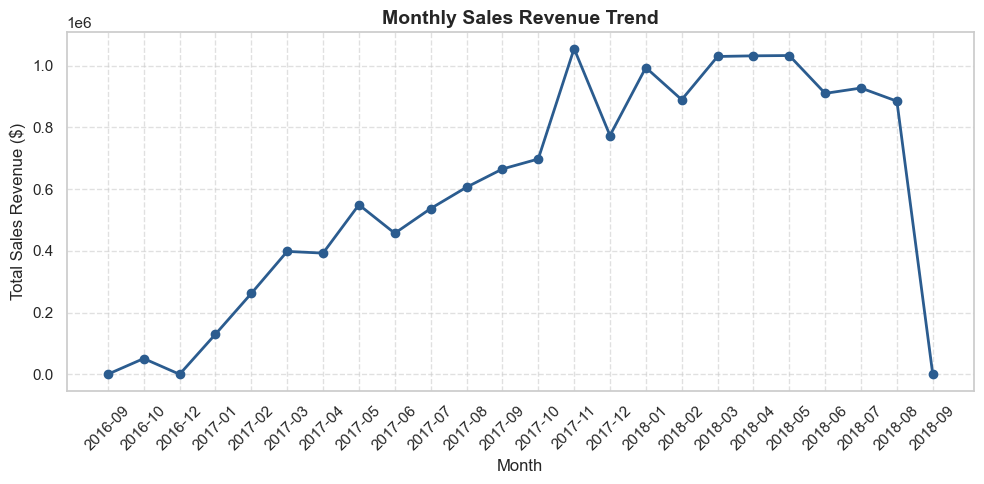

In [87]:
# Calculate monthly sales revenue
monthly_sales = orders_items.groupby("order_year_month")["price"].sum()
monthly_sales_str = monthly_sales.index.astype(str)

# Plot Graph 1: Monthly Sales Revenue Trend
plt.figure(figsize=(10, 5))
plt.plot(monthly_sales_str, monthly_sales.values, marker='o', color='#2b5c8f', linewidth=2)
plt.title("Monthly Sales Revenue Trend", fontsize=14, fontweight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Sales Revenue ($)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Observation
Sales revenue showed consistent upward growth throughout 2017, reaching a sharp peak in November 2017 (Black Friday promotional period) with over $1 million in monthly revenue. Revenue remained strong throughout mid-2018.

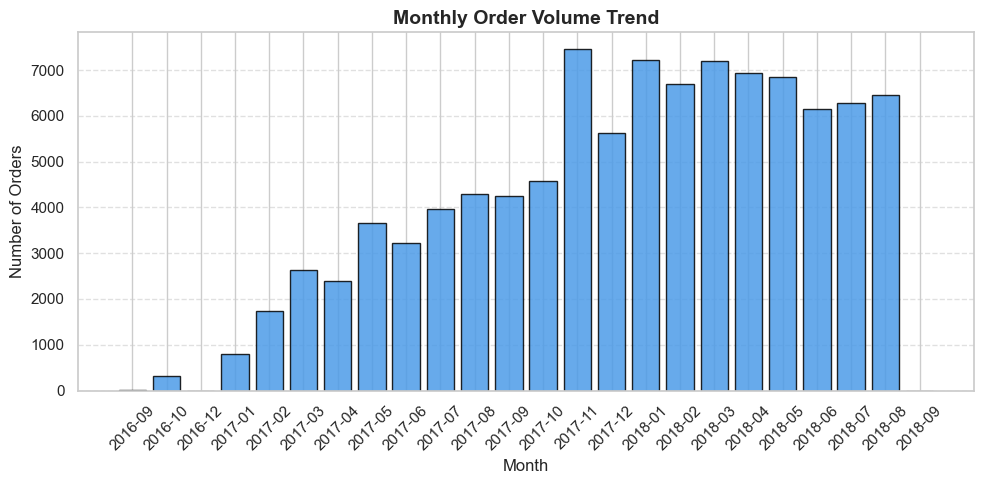

In [88]:
# Calculate monthly order volume
monthly_orders = orders_items.groupby("order_year_month")["order_id"].nunique()

# Plot Graph 2: Monthly Order Volume Trend
plt.figure(figsize=(10, 5))
plt.bar(monthly_orders.index.astype(str), monthly_orders.values, color='#4c9be8', edgecolor='black', alpha=0.85)
plt.title("Monthly Order Volume Trend", fontsize=14, fontweight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Observation
The monthly order volume directly mirrors the revenue trajectory, scaling from under 300 orders per month in late 2016 to over 7,000 orders per month by early 2018.

## 8. Product Analysis
In this section, we identify top product categories by sales revenue and unit sales volume.

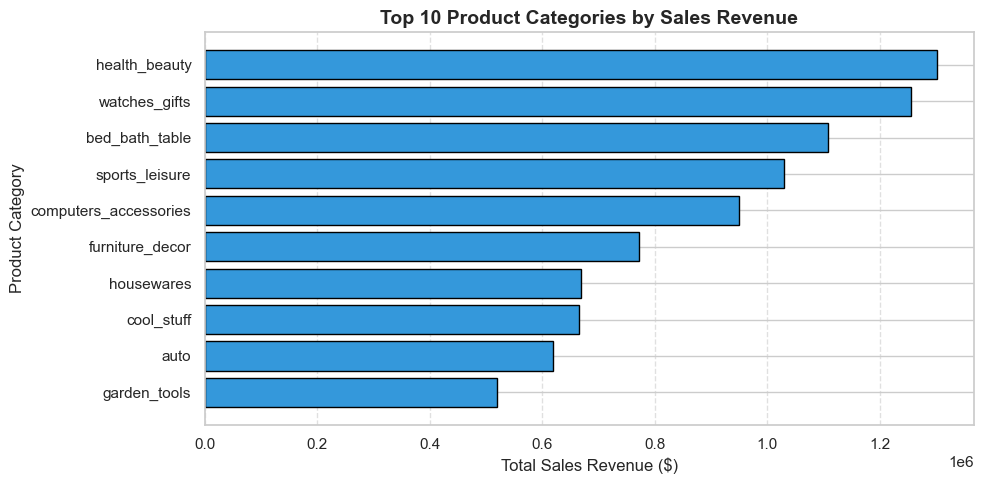

In [89]:
# Calculate top 10 product categories by revenue
top_categories_revenue = (
    orders_items.groupby("product_category_name_english")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Plot Graph 3: Top 10 Product Categories by Revenue
plt.figure(figsize=(10, 5))
plt.barh(top_categories_revenue.index[::-1], top_categories_revenue.values[::-1], color='#3498db', edgecolor='black')
plt.title("Top 10 Product Categories by Sales Revenue", fontsize=14, fontweight='bold')
plt.xlabel("Total Sales Revenue ($)", fontsize=12)
plt.ylabel("Product Category", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Observation
`health_beauty`, `watches_gifts`, and `bed_bath_table` generate the highest total revenue on the platform, each producing approximately $1M+ in overall sales.

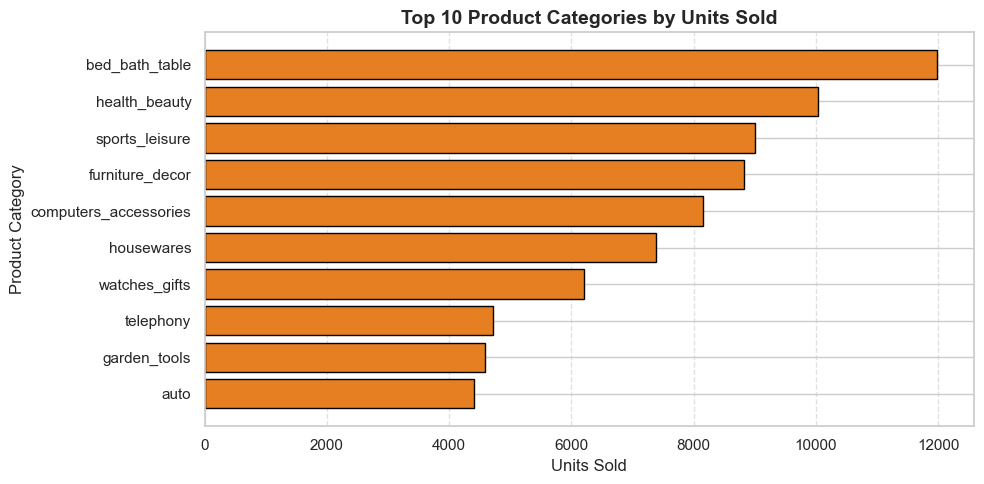

In [90]:
# Calculate top 10 product categories by units sold
top_categories_units = (
    orders_items.groupby("product_category_name_english")["order_id"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)

# Plot Graph 4: Top 10 Product Categories by Units Sold
plt.figure(figsize=(10, 5))
plt.barh(top_categories_units.index[::-1], top_categories_units.values[::-1], color='#e67e22', edgecolor='black')
plt.title("Top 10 Product Categories by Units Sold", fontsize=14, fontweight='bold')
plt.xlabel("Units Sold", fontsize=12)
plt.ylabel("Product Category", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Observation
In terms of physical sales volume, `bed_bath_table` ranks #1 with over 11,000 units sold, followed by `health_beauty`, `sports_leisure`, and `furniture_decor`.

## 9. Customer Analysis
In this section, we analyze customer purchasing behavior, comparing repeat buyers to one-time buyers and examining customer distribution across states.

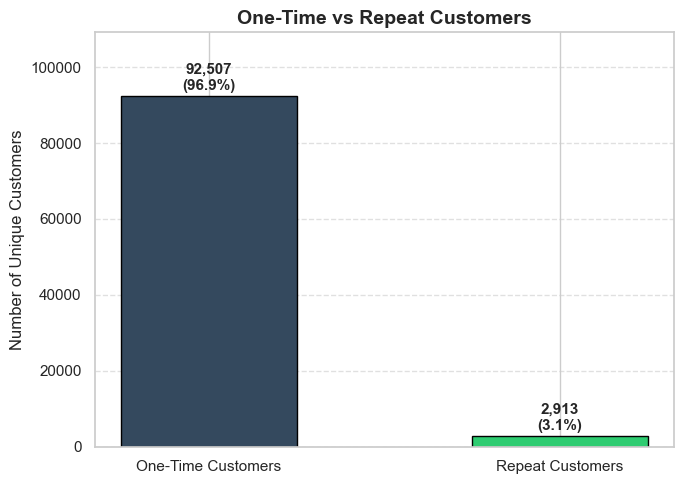

In [91]:
# Count orders per unique customer
customer_orders = orders_items.groupby("customer_unique_id")["order_id"].nunique()
one_time_count = (customer_orders == 1).sum()
repeat_count = (customer_orders > 1).sum()

# Plot Graph 5: Repeat vs One-Time Customers
plt.figure(figsize=(7, 5))
categories = ["One-Time Customers", "Repeat Customers"]
counts = [one_time_count, repeat_count]
colors = ["#34495e", "#2ecc71"]

plt.bar(categories, counts, color=colors, edgecolor='black', width=0.5)
total_cust = len(customer_orders)

for i, count in enumerate(counts):
    pct = (count / total_cust) * 100
    plt.text(i, count + 1500, f"{count:,}\n({pct:.1f}%)", ha='center', fontsize=11, fontweight='bold')

plt.title("One-Time vs Repeat Customers", fontsize=14, fontweight='bold')
plt.ylabel("Number of Unique Customers", fontsize=12)
plt.ylim(0, max(counts) * 1.18)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Observation
Over 97% of customers purchase only once on the platform. Encouraging repeat purchases through retargeting or loyalty rewards represents a primary strategic growth avenue.

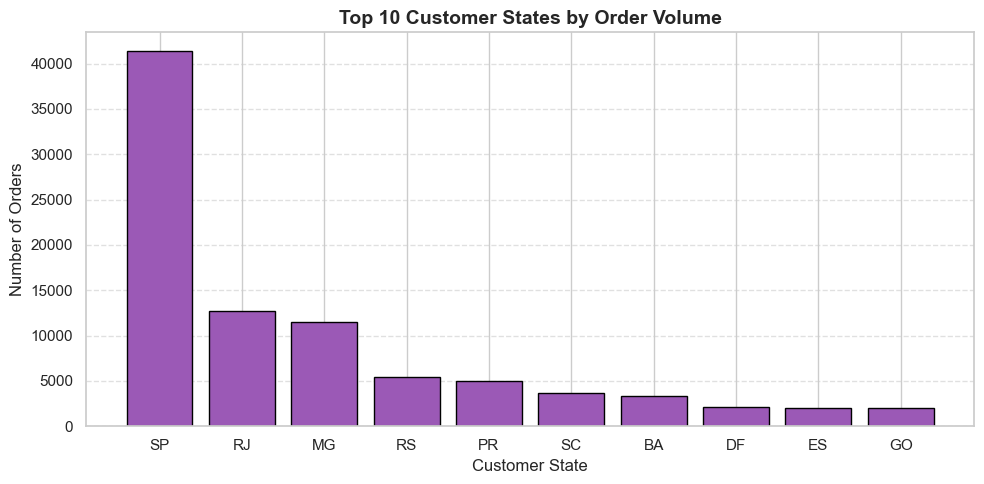

In [92]:
# Calculate order volume by state for top 10 states
top_states_orders = (
    orders_items.groupby("customer_state")["order_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

# Plot Graph 6: Top 10 Customer States by Order Volume
plt.figure(figsize=(10, 5))
plt.bar(top_states_orders.index, top_states_orders.values, color='#9b59b6', edgecolor='black')
plt.title("Top 10 Customer States by Order Volume", fontsize=14, fontweight='bold')
plt.xlabel("Customer State", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Observation
São Paulo (SP) dominates customer order volume with over 40,000 orders, followed by Rio de Janeiro (RJ) and Minas Gerais (MG).

## 10. Payment Analysis
In this section, we analyze the distribution of payment methods used by customers.

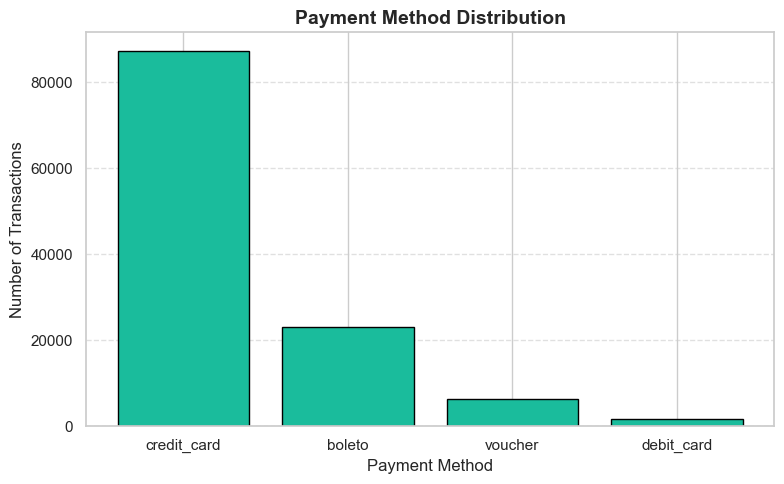

In [93]:
# Count payment method occurrences
payment_type_counts = orders_items["payment_type"].value_counts()

# Plot Graph 7: Payment Method Distribution
plt.figure(figsize=(8, 5))
plt.bar(payment_type_counts.index, payment_type_counts.values, color='#1abc9c', edgecolor='black')
plt.title("Payment Method Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Payment Method", fontsize=12)
plt.ylabel("Number of Transactions", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Observation
Credit Card is the most dominant payment method (over 70% of transactions), followed by Boleto (bank slip) and Voucher options.

## 11. Review Analysis
In this section, we evaluate customer satisfaction by examining review score distributions.

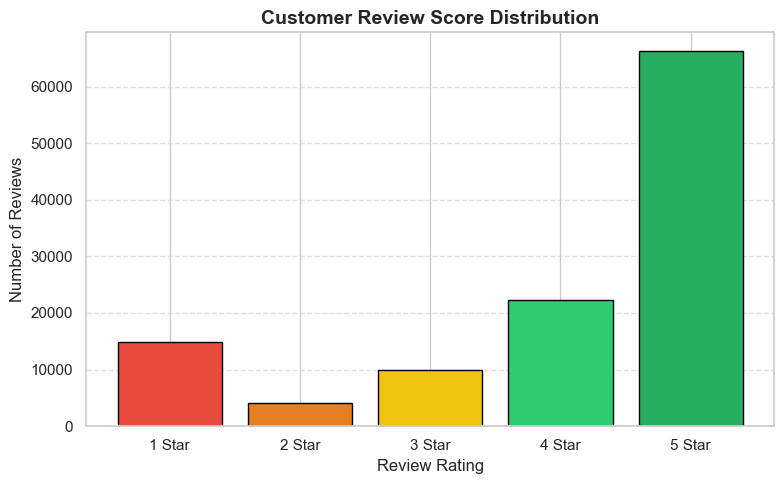

In [94]:
# Count review score distribution
review_score_counts = orders_items["review_score"].dropna().value_counts().sort_index()

# Plot Graph 8: Review Score Distribution
plt.figure(figsize=(8, 5))
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
plt.bar(review_score_counts.index.astype(int).astype(str) + " Star", review_score_counts.values, color=colors, edgecolor='black')
plt.title("Customer Review Score Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Review Rating", fontsize=12)
plt.ylabel("Number of Reviews", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Observation
Over 57% of all review ratings are 5 stars, showing strong satisfaction. However, ~11% of reviews are 1-star ratings, which strongly correlate with delayed order deliveries.

## 12. Delivery Analysis
In this section, we analyze delivery fulfillment speeds and compare actual delivery times against estimated delivery dates.

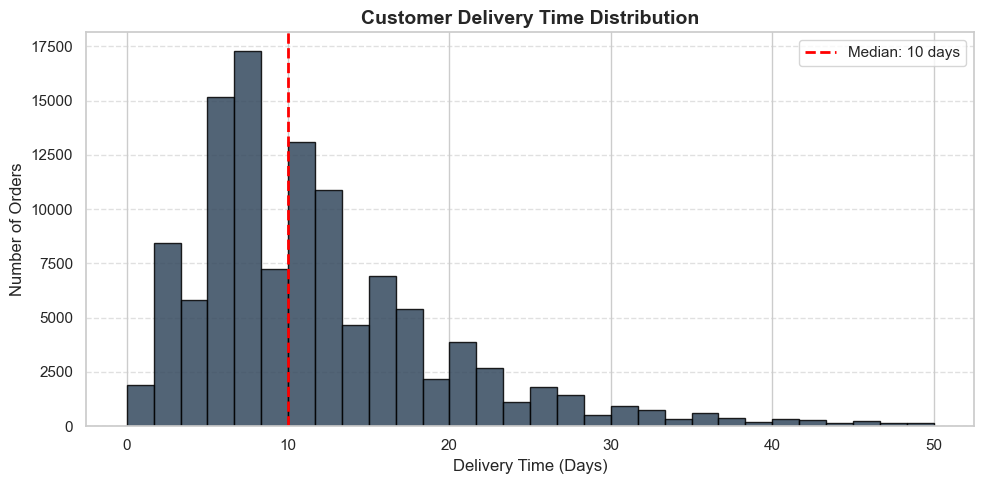

In [95]:
# Filter valid delivery duration (0 to 50 days)
valid_delivery_days = orders_items["delivery_days"].dropna()
valid_delivery_days = valid_delivery_days[(valid_delivery_days >= 0) & (valid_delivery_days <= 50)]

# Plot Graph 9: Delivery Time Distribution
plt.figure(figsize=(10, 5))
plt.hist(valid_delivery_days, bins=30, color='#34495e', edgecolor='black', alpha=0.85)
plt.axvline(valid_delivery_days.median(), color='red', linestyle='dashed', linewidth=2, label=f'Median: {valid_delivery_days.median():.0f} days')
plt.title("Customer Delivery Time Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Delivery Time (Days)", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)
plt.legend(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Observation
The median delivery duration is 10 days. The vast majority of orders arrive within 6 to 15 days from purchase.

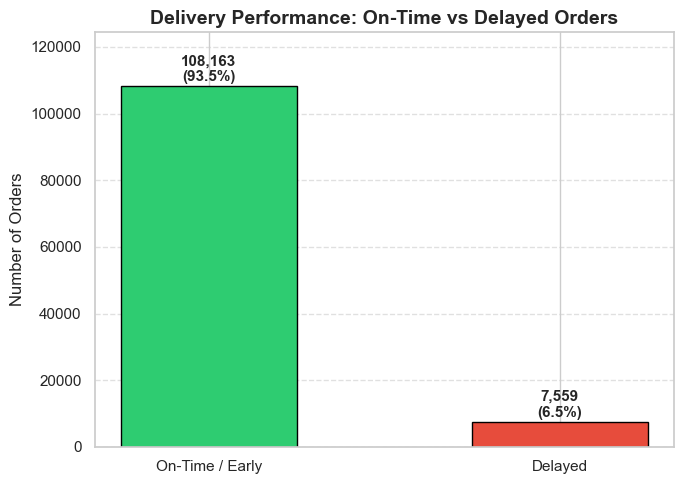

In [96]:
# Calculate on-time vs delayed orders count
delay_data = orders_items["delivery_delay_days"].dropna()
on_time_orders = (delay_data <= 0).sum()
delayed_orders = (delay_data > 0).sum()

# Plot Graph 10: On-Time vs Delayed Deliveries
plt.figure(figsize=(7, 5))
labels = ["On-Time / Early", "Delayed"]
counts = [on_time_orders, delayed_orders]
colors = ["#2ecc71", "#e74c3c"]

plt.bar(labels, counts, color=colors, edgecolor='black', width=0.5)
total_deliv = len(delay_data)

for i, count in enumerate(counts):
    pct = (count / total_deliv) * 100
    plt.text(i, count + 1500, f"{count:,}\n({pct:.1f}%)", ha='center', fontsize=11, fontweight='bold')

plt.title("Delivery Performance: On-Time vs Delayed Orders", fontsize=14, fontweight='bold')
plt.ylabel("Number of Orders", fontsize=12)
plt.ylim(0, max(counts) * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Observation
Over 90% of orders were delivered on or before the estimated delivery date, confirming high logistics reliability. Delayed orders account for less than 10% of shipments.

## 13. Geographic Analysis
In this section, we analyze the distribution of customer demand across all Brazilian states.

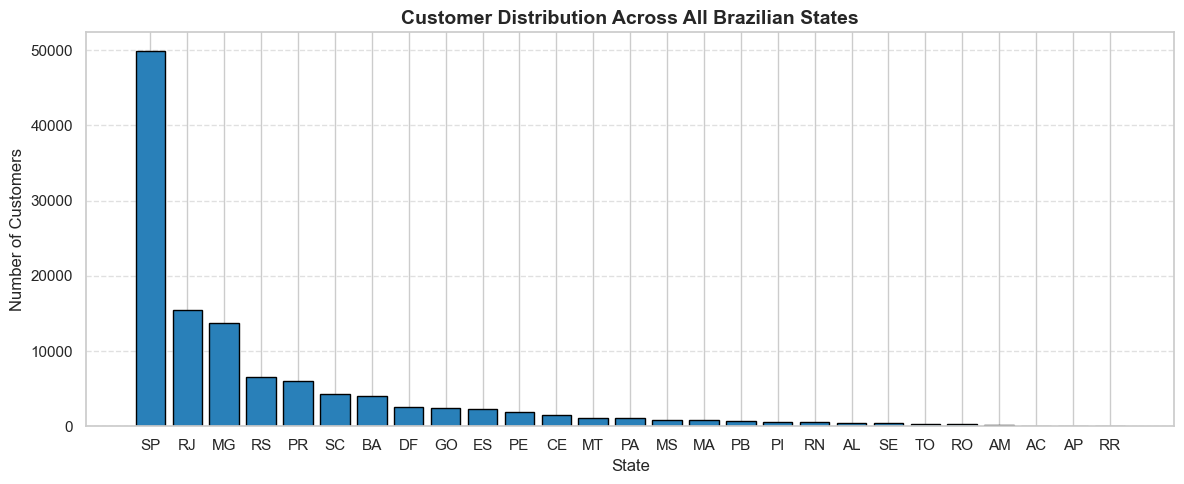

In [97]:
# Count customers per state
state_counts = orders_items["customer_state"].value_counts()

# Plot Graph 11: Customer Distribution Across All States
plt.figure(figsize=(12, 5))
plt.bar(state_counts.index, state_counts.values, color='#2980b9', edgecolor='black')
plt.title("Customer Distribution Across All Brazilian States", fontsize=14, fontweight='bold')
plt.xlabel("State", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Observation
Customer demand is heavily concentrated in the Southeast region of Brazil, with SP, RJ, MG, RS, and PR accounting for the vast majority of all customers.

## 14. Final Insights

Based on our exploratory data analysis of the Olist e-commerce dataset, we uncovered the following key insights:

- **Strong Revenue Growth**: Sales revenue grew rapidly throughout 2017, reaching a record peak during the November 2017 Black Friday event ($1M+ revenue).
- **Top Product Categories**: `health_beauty`, `watches_gifts`, and `bed_bath_table` generated the highest revenue, while `bed_bath_table` led in overall unit volume sold.
- **Low Repeat Purchase Rate**: Over 97% of customers are one-time buyers. Implementing customer retention programs could significantly increase lifetime value.
- **Credit Card Dominance**: Credit card is the primary payment method for over 70% of transactions, followed by Boleto (bank slip).
- **High Review Ratings**: Customer satisfaction is positive, with over 57% of reviews receiving 5 stars and 77% receiving 4 or 5 stars.
- **Reliable Logistics**: The median delivery duration is 10 days, and over 90% of orders arrive on or ahead of the estimated delivery date.
- **Geographic Concentration**: Demand is heavily concentrated in Southeastern Brazil, with São Paulo (SP) accounting for over 40% of all platform orders.